In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
# Load the new dataset with real station names
df = pd.read_csv(
    "../Data/whillans_events_with_velocity(in).csv",
    parse_dates=["start_time"]
)

# Sort by time
df = df.sort_values("start_time").reset_index(drop=True)

print(df.shape)
df.head()

(5150, 627)


,start_time,stations,vx_la09_pre,vy_la09_pre,v_la09_pre,n_la09_pre,vx_la09_post,vy_la09_post,v_la09_post,n_la09_post,...,v_pre_ws04,vx_pre_ws04,vy_pre_ws04,v30d_ws04,n_pre_ws04,v_pre_ws05,vx_pre_ws05,vy_pre_ws05,v30d_ws05,n_pre_ws05
0,2008-01-25 01:01:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-25 18:14:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-01-26 15:56:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-01-27 02:47:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-01-27 16:04:00,"la09,slw1",NaN,NaN,NaN,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Raw/event-level pre-event velocity columns
# ex: v_pre_gz01, v_pre_la09
pre_cols = [c for c in df.columns if c.startswith("v_pre_")]

# 30-day smoothed/background velocity columns
# ex: v30d_gz01, v30d_la09
v30d_cols = [c for c in df.columns if c.startswith("v30d_")]

# Extract station names from each column type
pre_stations = [c.replace("v_pre_", "") for c in pre_cols]
v30d_stations = [c.replace("v30d_", "") for c in v30d_cols]

# Keep only stations that have both pre-event and 30-day velocity
stations = sorted(list(set(pre_stations).intersection(set(v30d_stations))))

print("Number of stations:", len(stations))
print(stations)

Number of stations: 48
['gz01', 'gz02', 'gz03', 'gz04', 'gz05', 'gz06', 'gz07', 'gz08', 'gz09', 'gz10', 'gz11', 'gz12', 'gz13', 'gz14', 'gz15', 'gz16', 'gz17', 'gz18', 'gz19', 'gz20', 'la01', 'la02', 'la03', 'la04', 'la05', 'la06', 'la07', 'la08', 'la09', 'la10', 'la11', 'la12', 'la13', 'la14', 'la15', 'la16', 'la17', 'la18', 'mg01', 'mg02', 'mg03', 'mg04', 'mg05', 'mg06', 'mg07', 'slw1', 'ws04', 'ws05']


In [4]:
# Load station coordinates so station colors/order have spatial meaning
station_info = pd.read_csv("../Data/StationInformation.csv")

station_info = station_info.rename(columns={
    "Station": "station",
    "Starting X (PS71) [m]": "x",
    "Starting Y (PS71) [m]": "y"
})

station_info = station_info[["station", "x", "y"]]
station_info["station"] = station_info["station"].str.lower()

# Keep coordinates only for stations in this velocity dataset
station_coords = station_info[station_info["station"].isin(stations)].copy()

# Sort spatially by y coordinate
station_coords = station_coords.sort_values("y").reset_index(drop=True)

# This becomes the plotting order
stations_ordered = station_coords["station"].tolist()

print("Stations in spatial order:")
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return [1 - (1 - x) * (1 - amount) for x in c]
print(stations_ordered)

Stations in spatial order:
['gz09', 'gz10', 'gz11', 'gz01', 'gz02', 'gz03', 'gz04', 'gz20', 'gz05', 'gz06', 'gz07', 'gz16', 'gz08', 'gz17', 'gz15', 'gz14', 'gz19', 'gz12', 'gz18', 'gz13', 'la10', 'mg06', 'la03', 'mg05', 'ws04', 'ws05', 'la11', 'mg04', 'la02', 'slw1', 'la16', 'mg07', 'mg03', 'mg02', 'la13', 'la01', 'mg01', 'la15', 'la14', 'la06', 'la04', 'la07', 'la05', 'la08', 'la18', 'la09', 'la12', 'la17']


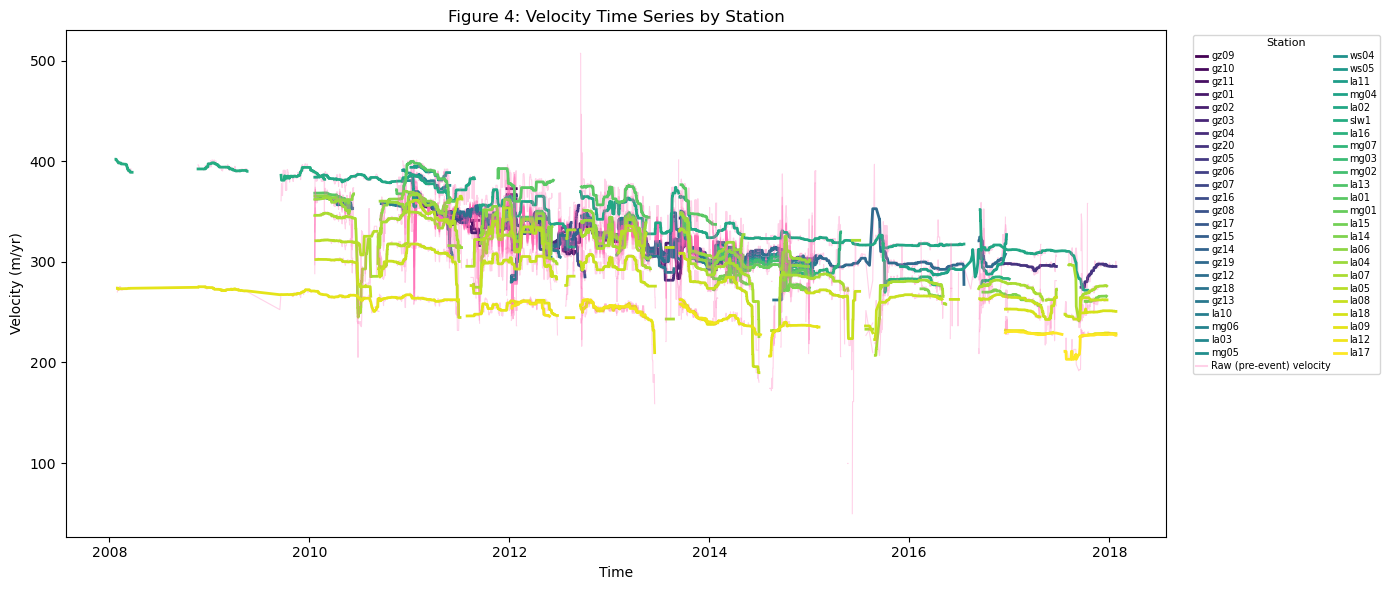

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.lines import Line2D

# Create colors based on spatial station order
colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(stations_ordered)))


fig, ax = plt.subplots(figsize=(14, 6))

# Loop through stations in spatial order
for station, color in zip(stations_ordered, colors):
    
    pre_col = f"v_pre_{station}"
    smooth_col = f"v30d_{station}"
    
    
    # Raw pre-event velocity (hot pink background)
    
    ax.plot(
        df["start_time"],
        df[pre_col],
        color="hotpink",
        alpha=0.3,
        linewidth=0.8
    )
    
   
    # 30-day smoothed/background velocity (main signal)
    
    ax.plot(
        df["start_time"],
        df[smooth_col],
        color=color,
        alpha=1.0,
        linewidth=2.0,
        label=station
    )


# Labels and title

ax.set_xlabel("Time")
ax.set_ylabel("Velocity (m/yr)")
ax.set_title("Figure 4: Velocity Time Series by Station")


# Custom legend entry for raw data

raw_handle = Line2D(
    [0], [0],
    color="hotpink",
    lw=1.5,
    alpha=0.3,
    label="Raw (pre-event) velocity"
)

# Get existing legend entries (stations)
handles, labels = ax.get_legend_handles_labels()

# Insert raw entry at position 24 (25th spot)
insert_idx = 24

handles.insert(insert_idx, raw_handle)
labels.insert(insert_idx, "Raw (pre-event) velocity")



# Legend

ax.legend(
    handles,
    labels,
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
    title_fontsize=8,
    ncol=2,
    columnspacing=0.3,   # reduces gap between columns
    handletextpad=0.4,   # space between line and text
    borderpad=0.3,       # padding inside legend box
    labelspacing=0.3,    # vertical spacing between rows
    handlelength=1.2     # shorter legend line symbols
)


plt.tight_layout()

plt.savefig(
    "../figures/figure4_velocity_timeseries_newdata.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 4 Interpertation

Figure 4 shows the velocity time series for each station, with the faint hot pink lines showing the raw pre-event velocity values and the darker colored lines showing the 30-day smoothed/background velocity. The raw data has a lot more short-term variability, which makes sense because individual pre-event values can jump around from event to event. The smoothed lines make the broader patterns easier to see by filtering out some of that noise.

Overall, many of the stations follow similar velocity patterns through time, suggesting that the ice plain is responding as a connected system rather than each station behaving completely independently. Some stations have consistently higher or lower velocities than others, which likely reflects their different spatial positions across the Whillans Ice Plain. The smoothed trends are useful because they show the longer-term changes in ice motion between 2008 and 2019, while the raw pink lines show how variable the event-level velocity measurements are around those background trends.